Notebook to assess MCS statistics from MPAS aquaplanet model output.

Fig. 5 of paper

Modified from code provided by Rosimar Rios-Berrios (NSF/NCAR).

James Ruppert  
jruppert@ou.edu  
3/14/26

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in linestrings",
    category=RuntimeWarning
)

In [2]:
EXPERIMENTS = ['CTL', 'CLIM_RAD_LW']

data_main = "./data/"
figdir = "./figures/"

minlat = 0
maxlat = 10

### Plotting functions

In [3]:
def get_pe(df_in):
    return 1 - (-df_in["mean_md"].fillna(0) / df_in["mean_mu"].replace(0, np.nan))

def prep_df(exp,
            cape_filter=False, cape_min=200, cape_max=50000,
            norm_time_filter=False, frac_keep=0.9,
            real_time_filter=False,
            end_timestep=24,
            min_duration_filter=False,
            min_duration=3.0):

    out_csv_name = f"{data_main}mcs_metrics_extended_{exp}.csv"
    df = pd.read_csv(out_csv_name)

    # remove rows with zero core_area_km2 as these likely are near the edges
    df = df.loc[df.core_area_km2 > 0.0].copy()
    # keep only stuff in the deep tropics
    df = df.loc[(df.centlat>=minlat) & (df.centlat <= maxlat)].copy()

    # Get area of light-raining area as precip_area_km2 - core_area_km2
    df["light_rain_km2"] = df["precip_area_km2"] - df["core_area_km2"]

    # Convert time to datetime
    df["time"] = pd.to_datetime(df["time"])
    # Ensure chronological order within each MCS
    df = df.sort_values(['ID', 'time'])

    # Filter by real time (hours)
    if real_time_filter:
        time_array = df['time'].unique()
        time_array = np.sort(time_array) # Ensure sorted order
        df = df.loc[df['time'] <= time_array[end_timestep]].copy()
    # calculate time since initiation (hours)
    df['time_since_init'] = df.groupby('ID')['time'].transform(
        lambda x: (x - x.iloc[0]).dt.total_seconds() / 3600 # +1
    )
    # normalized lifecycle (0–1)
    df['time_norm'] = df.groupby('ID')['time_since_init'].transform(
        lambda x: x / x.max()
    )

    # Minimum duration filter
    if min_duration_filter:
        df = df.loc[df['time_since_init'] >= min_duration].copy()

    # Scale area to convert to km^2
    df['area'] = df['area'] * 1e-6

    # Replace missing for CAPE (-100)
    df["mean_cape"] = df["mean_cape"].replace(-100, np.nan)
    df["mean_crh"] = df["mean_crh"].replace(-100, np.nan)
    df["mean_crh_mid"] = df["mean_crh_mid"].replace(-100, np.nan)
    # Replace missing for m_u (-100) and m_d (100)
    df["mean_mu"] = df["mean_mu"].replace(-100, np.nan)
    df["mean_md"] = df["mean_md"].replace(100, np.nan)

    # CAPE filter
    if cape_filter:
        df = df.loc[(df["mean_cape"] >= cape_min) & (df["mean_cape"] <= cape_max)].copy()
    # Normalized time filter
    if norm_time_filter:
        df = df.loc[df['time_norm'] <= frac_keep].copy()

    return df

def get_object_stats(df_in):
    df = df_in.copy()
    # --- Area and Lifetime per Object ---
    # Group by ID to calculate stats for each individual object
    # Area: We take the maximum area the object ever reaches (common for storm analysis)
    # Lifetime: Max time - Min time. We convert this to hours for easier plotting.
    object_stats = (
        df.groupby('ID')
        .agg(
            Lifetime=('time', lambda x: (x.max() - x.min()).total_seconds() / 3600 + 1.0), # hours, inclusive
            Max_Area=('area', 'max'),
            Mean_Area=('area', 'mean'),
            end_time=('time', 'max'),
            start_time=('time', 'min'),
            precip_area_km2=('precip_area_km2', 'mean'),
            core_area_km2=('core_area_km2', 'mean'),
            vol_rain_km3hr=('vol_rain_km3hr', 'mean'),
            max_pr_mmhr=('max_pr_mmhr', 'mean'),
            mean_cape=('mean_cape', np.nanmean),
            mean_crh=('mean_crh', np.nanmean),
            mean_crh_mid=('mean_crh_mid', np.nanmean),
            mean_mu=('mean_mu', np.nanmean),
            mean_md=('mean_md', np.nanmean)
        ).reset_index()
    )
    return object_stats

def get_lifetimes(df_in):
    object_stats = get_object_stats(df_in)
    return object_stats["Lifetime"].to_numpy()

def scale_values(value, tick_number):
    """
    Formats the tick value by multiplying it with a scaling factor
    and adding a dollar sign.
    """
    scaling_factor = 1e-3
    scaled_value = value * scaling_factor
    return scaled_value # Format to 2 decimal places

In [4]:
def plot_hists(ax, data, color, do_scaling=False, stat='density'):
    sns.histplot(ax=ax, data=data, bins=50, stat=stat,
                 fill=False, element='step', common_norm=False, color=color)
    ax.set_yscale('log')
    sns.despine(offset=5, ax=ax, top=True, right=True)#, bottom=True)

def add_quantile_lines(ax, x, color):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    # q50, 
    q75, q95 = np.quantile(x, [0.75, 0.95])
    # ax.axvline(q50, color=color, lw=2)
    # ax.axvline(q75, color=color, lw=1, ls="--")
    ax.axvline(q95, color=color, lw=1, ls="--")
    print(f"95th= {q95:.2f}")

def plot_ccdf(ax, x, color, label=None):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    n = x.size
    y = 1.0 - (np.arange(1, n+1) / n)  # survival = P(X > x)
    add_quantile_lines(ax, x, color)
    ax.step(x, y, where="post", color=color, label=label)

### Combined MCS tracks and TC statistics

/var/folders/9x/209ltwrn2b359nrrh4638hv40000gp/T/ipykernel_14009/934702774.py:74: FutureWarning: The provided callable <function nanmean at 0x121e4ab60> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  .agg(


95th= 0.68
95th= 104.88
95th= 75.50


/var/folders/9x/209ltwrn2b359nrrh4638hv40000gp/T/ipykernel_14009/934702774.py:74: FutureWarning: The provided callable <function nanmean at 0x121e4ab60> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  .agg(


95th= 0.66
95th= 78.55
95th= 40.40


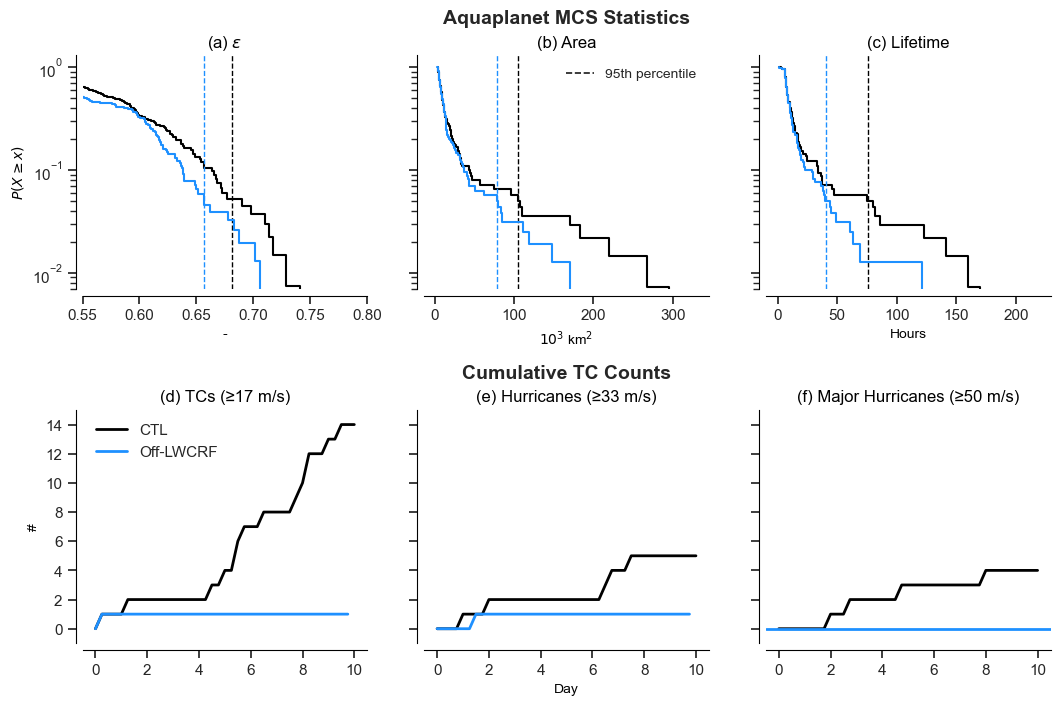

In [5]:
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

# =============================================================================
# Helper functions from analysis_of_TC_statistics (needed for bottom row)
# =============================================================================

def read_TC_tracks(expName, tracker, latThreshold):
    if tracker == 'TE':
        filename = f'{data_main}tc_tracks_{expName}.txt'
        dfMain = pd.read_csv(filename, header=1,
                             names=['ID','year','month','day','hour','i','lon','lat','pmin','vmax'])
        dfMain['datetime'] = pd.to_datetime(dfMain[['year','month','day','hour']])
        dfMain['valid_time'] = pd.to_datetime(dfMain[['year','month','day','hour']]).dt.strftime("%Y-%m-%d_%H.%M.%S")
    dfMain = dfMain[(dfMain.lat >= 0.0) & (dfMain.lat <= latThreshold)]
    dfMain = dfMain[dfMain.datetime <= '2000-05-11']
    return dfMain

def cumulative_tc_counts_by_threshold(
    df, *, id_col="track_id", time_col="datetime", wind_col="wind",
    thresholds=(17., 33., 50., 70.), do_remove_init=False, freq="6h",
):
    d = df[[id_col, time_col, wind_col]].copy()
    d[time_col] = pd.to_datetime(d[time_col])
    out = {}
    for thr in thresholds:
        reached = d.loc[d[wind_col] >= thr, [id_col, time_col]]
        first_hit = reached.groupby(id_col)[time_col].min()
        ts = first_hit.dt.floor(freq).value_counts().sort_index()
        if len(first_hit) == 0:
            t_index = pd.date_range(d[time_col].min().floor(freq),
                                    d[time_col].max().floor(freq), freq=freq)
            out[thr] = pd.Series(0, index=t_index)
        else:
            t_index = pd.date_range(
                min(first_hit.min().floor(freq), d[time_col].min().floor(freq)),
                max(first_hit.max().floor(freq), d[time_col].max().floor(freq)),
                freq=freq)
            out[thr] = ts.reindex(t_index, fill_value=0).cumsum()
    if do_remove_init:
        for thr in thresholds:
            out[thr] = out[thr] - out[thr].iloc[0]
    cdf = pd.DataFrame(out)
    cdf.index.name = time_col
    return cdf

# =============================================================================
# Figure: 3 columns × 2 rows
#   Top row:    epsilon (PE), MCS Area, MCS Lifetime
#   Bottom row: Cumulative TCs, Hurricanes, Major Hurricanes
# =============================================================================

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(11, 7),
                        gridspec_kw={'hspace': 0.52},
                        constrained_layout=False)
fig.subplots_adjust(left=0.08, right=0.96, top=0.92, bottom=0.08)

# colors = sns.color_palette('muted', n_colors=2)
sns.set_theme(style="ticks", font_scale=1.)
colors = ['black', 'dodgerblue']

# -----------------------------------------------------------------
# TOP ROW — MCS CCDFs (epsilon, area, lifetime)
# -----------------------------------------------------------------
for iexp, exp in enumerate(EXPERIMENTS):

    df_plot = prep_df(exp, cape_filter=False,norm_time_filter=False,real_time_filter=False)
    object_stats = get_object_stats(df_plot)
    end_timestep = 2*24

    # Filter for max time
    real_time_filter = True
    if real_time_filter:
        # Actual max time is 2000-05-11T01:00:00
        time_array = np.sort(df_plot['time'].unique())
        max_time = time_array[end_timestep]
        time_reference = 'start_time'
        object_stats = object_stats.loc[object_stats[time_reference] <= max_time].copy()

    lifetimes = object_stats["Lifetime"].to_numpy()
    df_plot = object_stats

    # Set universal y-limits for top row
    ylim = (7e-3, 1.3)
    # ylim = None

    # (a) Epsilon (PE)
    iax = ax[0, 0]
    plot_ccdf(iax, get_pe(df_plot), colors[iexp], label=exp)
    iax.set_ylabel(r'$P(X \geq x)$')
    iax.set_yscale("log")
    iax.set_title(r'(a) $\epsilon$')
    iax.set_xlabel('-')
    iax.set_xlim(0.55, 0.8)
    iax.set_ylim(ylim)

    # (b) MCS Area
    iax = ax[0, 1]
    plot_ccdf(iax, df_plot["precip_area_km2"] * 1e-3, colors[iexp], label=exp)
    iax.set_yscale("log")
    iax.set_title('(b) Area')
    iax.set_xlabel(r'$10^3$ km$^2$')
    iax.set_ylim(ylim)

    # (c) MCS Lifetime
    iax = ax[0, 2]
    plot_ccdf(iax, lifetimes, colors[iexp], label=exp)
    iax.set_yscale("log")
    iax.set_title('(c) Lifetime')
    iax.set_xlabel('Hours')
    iax.set_ylim(ylim)

# Top-row legends
quant_handles = [
    Line2D([0], [0], color='k', lw=1.2, ls='--', label='95th percentile'),
]
ax[0, 1].legend(handles=quant_handles, fontsize=10, frameon=False, loc="upper right")

# -----------------------------------------------------------------
# BOTTOM ROW — Cumulative TC counts (replicates cell 10 of
#              analysis_of_TC_statistics.ipynb)
# -----------------------------------------------------------------
thresholds = (17., 33., 50.)
panel_labels = [
    '(d) TCs (≥17 m/s)',
    '(e) Hurricanes (≥33 m/s)',
    '(f) Major Hurricanes (≥50 m/s)',
]

exp_names = ['CTL', 'Off-LWCRF']

for i, thr in enumerate(thresholds):
    iax = ax[1, i]
    for iexp, exp in enumerate(EXPERIMENTS):
        df_tc = read_TC_tracks(exp, 'TE', 35.0)
        cdf = cumulative_tc_counts_by_threshold(
            df_tc,
            id_col='ID',
            time_col='datetime',
            wind_col='vmax',
            thresholds=[thr],
            do_remove_init=True,
            freq='6h',
        )
        t0 = cdf.index.min()
        days = (cdf.index - t0).total_seconds() / 86400.0
        if np.max(cdf[thr]) > 0:
            iax.plot(days, cdf[thr], color=colors[iexp], linewidth=2, label=exp_names[iexp])#exp)
        else:
            iax.axhline(0, color=colors[iexp], linewidth=2, label=exp)

    iax.set_title(panel_labels[i])
    iax.yaxis.set_major_locator(MaxNLocator(integer=True))
    # sns.despine(ax=iax, offset=10, right=True, top=True)
    iax.set_ylim((-1,15))

ax[1, 1].set_xlabel("Day")
ax[1, 0].set_ylabel("#")
handles, labels = ax[1, 0].get_legend_handles_labels()
ax[1, 0].legend(handles, labels, frameon=False)

# Despine top row
for i, iax in enumerate(ax.flatten()):
    sns.despine(offset=5, ax=iax, top=True, right=True)
    if i != 0 and i != 3:
        iax.set_ylabel('')
        iax.set_yticklabels([])

# Add titles top and bottom rows
# plt.suptitle(suptitle)
y_offset = 0.12
ax[0,1].annotate('Aquaplanet MCS Statistics',
            xy=(0.5, 1+y_offset), xycoords='axes fraction',
            ha='center', va='bottom', fontsize=14, fontweight='bold')
ax[1,1].annotate('Cumulative TC Counts',
            xy=(0.5, 1+y_offset), xycoords='axes fraction',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.savefig(f"{figdir}/mpas_mcs_tc_comparison.png", dpi=400, facecolor='white',
        bbox_inches='tight')
plt.show()
plt.close()